## 기본 설정

In [56]:
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# 프로젝트 루트의 .env 불러오기 (notebooks 폴더 기준 상위 폴더)
load_dotenv("../.env")
SERVICE_KEY = os.getenv("SERVICE_KEY")

TOUR_BASE_URL = "https://apis.data.go.kr/B551011/KorService2"
REGIONS = {"광주": "5", "전남": "38"}

CONTENT_TYPE_NAMES = {
    "12": "관광지", "14": "문화시설", "15": "축제공연행사",
    "25": "여행코스", "28": "레포츠", "32": "숙박",
    "38": "쇼핑", "39": "음식점",
}

plt.rcParams['font.family'] = 'Malgun Gothic'  # 맥이면 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

## 관광지 수집

In [57]:
def get_area_based_list_all(area_code, content_type_id=None, num_of_rows=100):
    """지역기반 관광정보를 페이지 끝까지 순회하며 전체 가져오기"""
    all_items = []
    page_no = 1
    while True:
        url = f"{TOUR_BASE_URL}/areaBasedList2"
        params = {
            "serviceKey": SERVICE_KEY,
            "MobileOS": "ETC",
            "MobileApp": "MyApp",
            "_type": "json",
            "areaCode": area_code,
            "numOfRows": num_of_rows,
            "pageNo": page_no,
        }
        if content_type_id:
            params["contentTypeId"] = content_type_id

        res = requests.get(url, params=params)
        data = res.json()
        body = data["response"]["body"]

        items = body.get("items", {})
        items = items.get("item", []) if isinstance(items, dict) else []
        if not items:
            break

        all_items.extend(items)
        page_no += 1

        if len(items) < num_of_rows:
            break

    return all_items

In [58]:
def get_gwangju_jeonnam_attractions_all():
    """광주 + 전남 전체 관광지 가져오기"""
    all_attractions = []
    for region_name, area_code in REGIONS.items():
        items = get_area_based_list_all(area_code)
        for item in items:
            item["_region"] = region_name
        all_attractions.extend(items)
    return all_attractions

In [59]:
raw_items = get_gwangju_jeonnam_attractions_all()
print(f"총 {len(raw_items)}개 관광지 수집")

총 1882개 관광지 수집


## 분류체계 매핑표

In [60]:
def get_lcls_codes(lcls1=None, lcls2=None, num_of_rows=100):
    url = f"{TOUR_BASE_URL}/lclsSystmCode2"
    params = {
        "serviceKey": SERVICE_KEY,
        "MobileOS": "ETC",
        "MobileApp": "MyApp",
        "_type": "json",
        "numOfRows": num_of_rows,
    }
    if lcls1:
        params["lclsSystm1"] = lcls1
    if lcls2:
        params["lclsSystm2"] = lcls2

    res = requests.get(url, params=params)
    data = res.json()
    items = data["response"]["body"]["items"]["item"]
    return {item["code"]: item["name"] for item in items}

In [61]:
def build_full_lcls_mapping():
    full_map = {}
    lcls1_map = get_lcls_codes()
    full_map.update(lcls1_map)
    for lcls1_code in lcls1_map:
        lcls2_map = get_lcls_codes(lcls1=lcls1_code)
        full_map.update(lcls2_map)
        for lcls2_code in lcls2_map:
            lcls3_map = get_lcls_codes(lcls1=lcls1_code, lcls2=lcls2_code)
            full_map.update(lcls3_map)
    return full_map

lcls_full_map = build_full_lcls_mapping()

## 시군구 매핑표

In [62]:
def get_sigungu_map(area_code):
    url = f"{TOUR_BASE_URL}/areaCode2"
    params = {
        "serviceKey": SERVICE_KEY,
        "MobileOS": "ETC",
        "MobileApp": "MyApp",
        "_type": "json",
        "areaCode": area_code,
        "numOfRows": 100,
    }
    res = requests.get(url, params=params)
    data = res.json()
    items = data["response"]["body"]["items"]["item"]
    return {item["code"]: item["name"] for item in items}

sigungu_full_map = {}
for area_code in REGIONS.values():
    sigungu_map = get_sigungu_map(area_code)
    for code, name in sigungu_map.items():
        sigungu_full_map[f"{area_code}_{code}"] = name

print(f"시군구 {len(sigungu_full_map)}개 확보")

시군구 27개 확보


## 관광지 전처리

In [63]:
def combine_address(item):
    addr1 = item.get("addr1", "") or ""
    addr2 = item.get("addr2", "") or ""
    return f"{addr1} {addr2}".strip()

In [64]:
def preprocess_attraction(item):
    area_code = item.get("areacode")
    sigungu_code = item.get("sigungucode")
    sigungu_key = f"{area_code}_{sigungu_code}"

    return {
        "content_id": item.get("contentid"),
        "name": item.get("title"),
        "address": combine_address(item),
        "image": item.get("firstimage") or None,
        "category": CONTENT_TYPE_NAMES.get(item.get("contenttypeid"), "기타"),
        "lcls1_name": lcls_full_map.get(item.get("lclsSystm1"), "미분류"),
        "lcls2_name": lcls_full_map.get(item.get("lclsSystm2"), "미분류"),
        "lcls3_name": lcls_full_map.get(item.get("lclsSystm3"), "미분류"),
        "area_code": area_code,
        "sigungu_name": sigungu_full_map.get(sigungu_key, "기타"),
        "lat": float(item["mapy"]) if item.get("mapy") else None,
        "lng": float(item["mapx"]) if item.get("mapx") else None,
        "tel": item.get("tel") or None,
        "region": item.get("_region"),
    }

In [65]:
df = pd.DataFrame([preprocess_attraction(i) for i in raw_items])
df = df.drop_duplicates(subset="content_id")
df = df.dropna(subset=["name", "lat", "lng"])

print("전처리 후 관광지 데이터 크기:", df.shape)
df.head()

전처리 후 관광지 데이터 크기: (1882, 14)


,content_id,name,address,image,category,lcls1_name,lcls2_name,lcls3_name,area_code,sigungu_name,lat,lng,tel,region
0,2859186,가배당,전남광주통합특별시 서구 눌재로 434 1층,http://tong.visitkorea.or.kr/cms/resource/68/2...,음식점,음식,카페/ 찻집,카페,5,서구,35.116427,126.830377,NaN,광주
1,2664961,개마고원,전남광주통합특별시 서구 상무대로 1094,http://tong.visitkorea.or.kr/cms/resource/04/2...,음식점,음식,한식,관광식당,5,서구,35.152549,126.881472,NaN,광주
2,2874038,갤러리24,전남광주통합특별시 서구 천변좌로 14,http://tong.visitkorea.or.kr/cms/resource/27/2...,음식점,음식,카페/ 찻집,카페,5,서구,35.166519,126.884796,NaN,광주
3,2783851,경암근린공원,전남광주통합특별시 광산구 하남대로54번안길 133 (하남동),http://tong.visitkorea.or.kr/cms/resource/84/3...,관광지,문화관광,도시공원,근린공원,5,광산구,35.178322,126.800098,NaN,광주
4,2664541,계림동잔치집,전남광주통합특별시 동구 무등로306번길 6-1 (계림동),http://tong.visitkorea.or.kr/cms/resource/22/3...,음식점,음식,한식,관광식당,5,동구,35.161865,126.916088,NaN,광주


## 시장 데이터 불러오기 + 전처리

In [66]:
df_market_raw = pd.read_csv(
    "../data/raw/market/소상공인시장진흥공단_전통시장_20251110.csv",
    encoding="utf-8-sig",
)

def combine_market_address(row):
    road_addr = row.get("소재지도로명주소")
    lot_addr = row.get("소재지지번주소")
    if pd.notna(road_addr) and str(road_addr).strip():
        return str(road_addr).strip()
    elif pd.notna(lot_addr) and str(lot_addr).strip():
        return str(lot_addr).strip()
    return None

In [123]:
def preprocess_market(row):
    return {
        "name": row.get("시장명"),
        "market_type": row.get("시장유형"),
        "address": combine_market_address(row),
        "open_cycle": row.get("시장개설주기"),
        "lat": float(row["위도"]) if pd.notna(row.get("위도")) else None,
        "lng": float(row["경도"]) if pd.notna(row.get("경도")) else None,
        "items": str(row["취급품목"]).split("+") if pd.notna(row.get("취급품목")) else [],
        "has_restroom": row.get("공중화장실보유여부") == "Y",
        "has_parking": row.get("주차장보유여부") == "Y",
        "store_count": pd.to_numeric(row.get("점포수"), errors="coerce"),
    }

In [124]:
df_market = pd.DataFrame([preprocess_market(row) for _, row in df_market_raw.iterrows()])
df_market = df_market.dropna(subset=["name", "lat", "lng"])
df_market = df_market.drop_duplicates(subset=["name", "address"])

df_market_gj = df_market[df_market["address"].str.contains("광주광역시|전라남도", na=False)]

# 확인: items 컬럼이 리스트로 잘 쪼개졌는지
print(df_market_gj["items"].iloc[0])

['농산물', '축산물', '수산물', '가공식품', '의류', '신발', '가정용품', '음식점']


## 관광지 지역별 개수

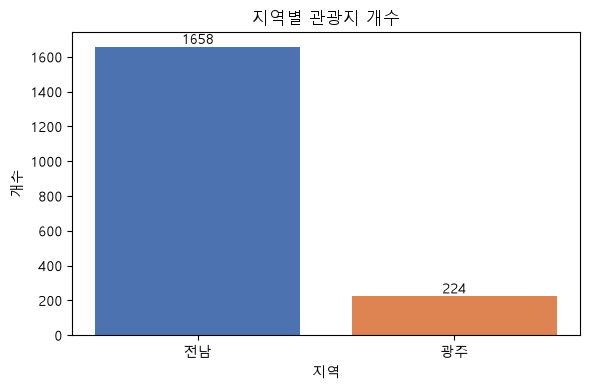

In [94]:
region_counts = df["region"].value_counts()
plt.figure(figsize=(6, 4))
bars = plt.bar(region_counts.index, region_counts.values, color=["#4C72B0", "#DD8452"])
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, int(h), ha="center", va="bottom")
plt.title("지역별 관광지 개수")
plt.xlabel("지역"); plt.ylabel("개수"); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## 관광지 카테고리별 개수

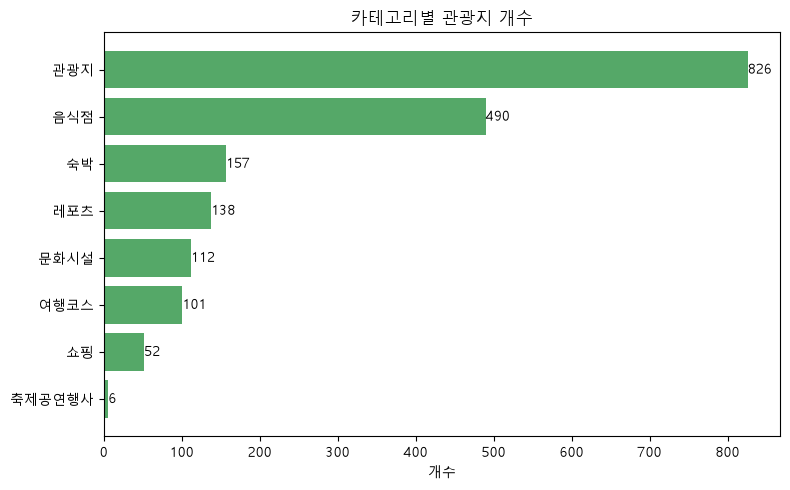

In [95]:
category_counts = df["category"].value_counts()
plt.figure(figsize=(8, 5))
bars = plt.barh(category_counts.index, category_counts.values, color="#55A868")
for bar in bars:
    w = bar.get_width()
    plt.text(w, bar.get_y()+bar.get_height()/2, int(w), ha="left", va="center")
plt.title("카테고리별 관광지 개수")
plt.xlabel("개수"); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

## 관광지 시군구별 개수

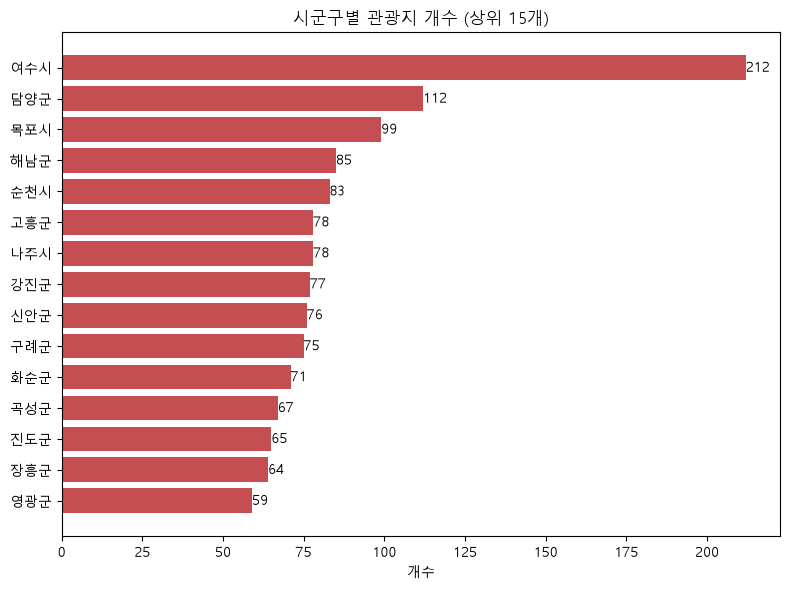

In [96]:
sigungu_counts = df["sigungu_name"].value_counts().head(15)
plt.figure(figsize=(8, 6))
bars = plt.barh(sigungu_counts.index, sigungu_counts.values, color="#C44E52")
for bar in bars:
    w = bar.get_width()
    plt.text(w, bar.get_y()+bar.get_height()/2, int(w), ha="left", va="center")
plt.title("시군구별 관광지 개수 (상위 15개)")
plt.xlabel("개수"); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

## 시장 지역별 개수

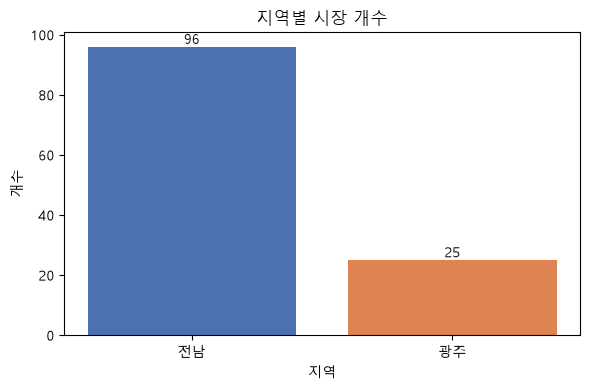

In [126]:
df_market_gj["is_gwangju"] = df_market_gj["address"].str.contains("광주광역시")
market_region_counts = df_market_gj["is_gwangju"].map({True: "광주", False: "전남"}).value_counts()
plt.figure(figsize=(6, 4))
bars = plt.bar(market_region_counts.index, market_region_counts.values, color=["#4C72B0", "#DD8452"])
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h, int(h), ha="center", va="bottom")
plt.title("지역별 시장 개수")
plt.xlabel("지역"); plt.ylabel("개수"); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## 시장 개설주기 분포

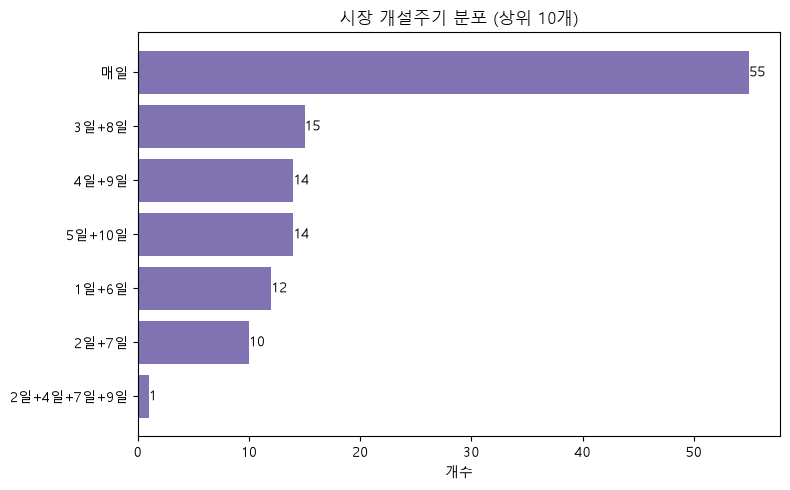

In [127]:
cycle_counts = df_market_gj["open_cycle"].value_counts().head(10)
plt.figure(figsize=(8, 5))
bars = plt.barh(cycle_counts.index, cycle_counts.values, color="#8172B2")
for bar in bars:
    w = bar.get_width()
    plt.text(w, bar.get_y()+bar.get_height()/2, int(w), ha="left", va="center")
plt.title("시장 개설주기 분포 (상위 10개)")
plt.xlabel("개수"); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

## 시장 점포수 분포

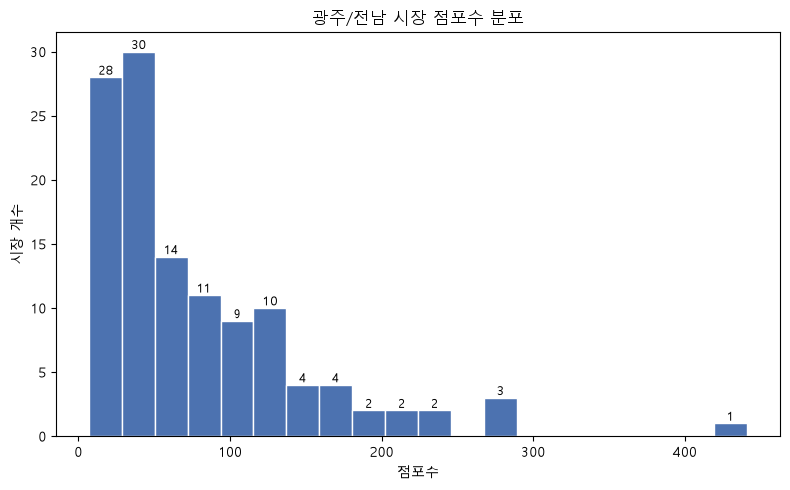

In [128]:
plt.figure(figsize=(8, 5))
n, bins, patches = plt.hist(df_market_gj["store_count"].dropna(), bins=20, color="#4C72B0", edgecolor="white")

# 각 막대 위에 개수 표시 (0인 막대는 생략)
for count, left_edge, right_edge in zip(n, bins[:-1], bins[1:]):
    if count > 0:
        center = (left_edge + right_edge) / 2
        plt.text(center, count, int(count), ha="center", va="bottom", fontsize=9)

plt.title("광주/전남 시장 점포수 분포")
plt.xlabel("점포수")
plt.ylabel("시장 개수")
plt.tight_layout()
plt.show()

## 점포수 이상치

C:\Users\kbr97\AppData\Local\Temp\ipykernel_16508\534301915.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_market_gj["store_count"].dropna(), vert=False)


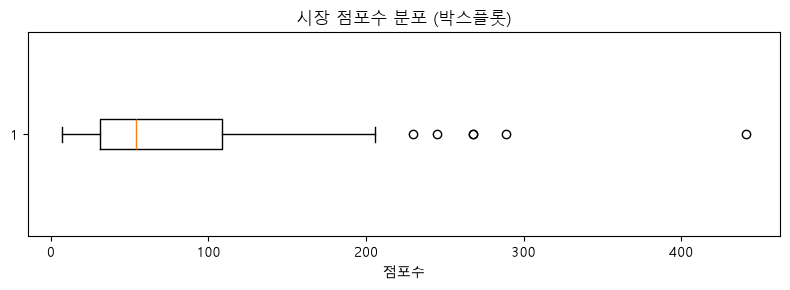

In [129]:
plt.figure(figsize=(8, 3))
plt.boxplot(df_market_gj["store_count"].dropna(), vert=False)
plt.title("시장 점포수 분포 (박스플롯)")
plt.xlabel("점포수")
plt.tight_layout()
plt.show()

## 관광지/시장이 몰린 정도

In [101]:
# 한국 범위를 벗어난 이상한 좌표 확인 (한국은 대략 위도 33~39, 경도 124~132)
print("관광지 이상 좌표:")
print(df[(df["lat"] < 30) | (df["lat"] > 40) | (df["lng"] < 120) | (df["lng"] > 135)][["name", "lat", "lng"]])

print("\n전통시장 이상 좌표:")
print(df_market_gj[(df_market_gj["lat"] < 30) | (df_market_gj["lat"] > 40) | (df_market_gj["lng"] < 120) | (df_market_gj["lng"] > 135)][["name", "lat", "lng"]])

관광지 이상 좌표:
                name        lat         lng
412           급치산전망대  19.694427  117.992566
471      남파랑길(여수 구간)   0.000000    0.000000
472  남파랑길(해남, 강진 구간)   0.000000    0.000000
536       담양 메타세쿼이아길   0.000000    0.000000
559              담양호  19.694427  117.992566
601           도리산전망대  19.694427  117.992566
864       보성 대원사 벚꽃길   0.000000    0.000000
952   서해랑길(진도, 목포구간)   0.000000    0.000000

전통시장 이상 좌표:
Empty DataFrame
Columns: [name, lat, lng]
Index: []


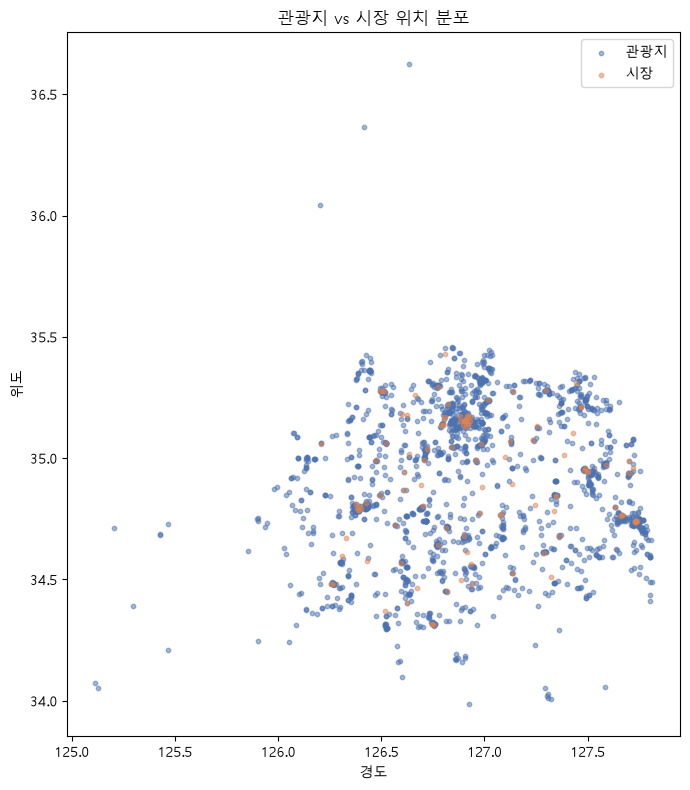

In [131]:
# 한국 범위 안의 데이터만 필터링
df_valid = df[(df["lat"].between(30, 40)) & (df["lng"].between(120, 135))]
df_market_valid = df_market_gj[(df_market_gj["lat"].between(30, 40)) & (df_market_gj["lng"].between(120, 135))]

plt.figure(figsize=(7, 8))
plt.scatter(df_valid["lng"], df_valid["lat"], s=10, alpha=0.5, color="#4C72B0", label="관광지")
plt.scatter(df_market_valid["lng"], df_market_valid["lat"], s=10, alpha=0.5, color="#DD8452", label="시장")
plt.title("관광지 vs 시장 위치 분포")
plt.xlabel("경도")
plt.ylabel("위도")
plt.legend()
plt.tight_layout()
plt.show()

## 시군구, 카테고리 교차표

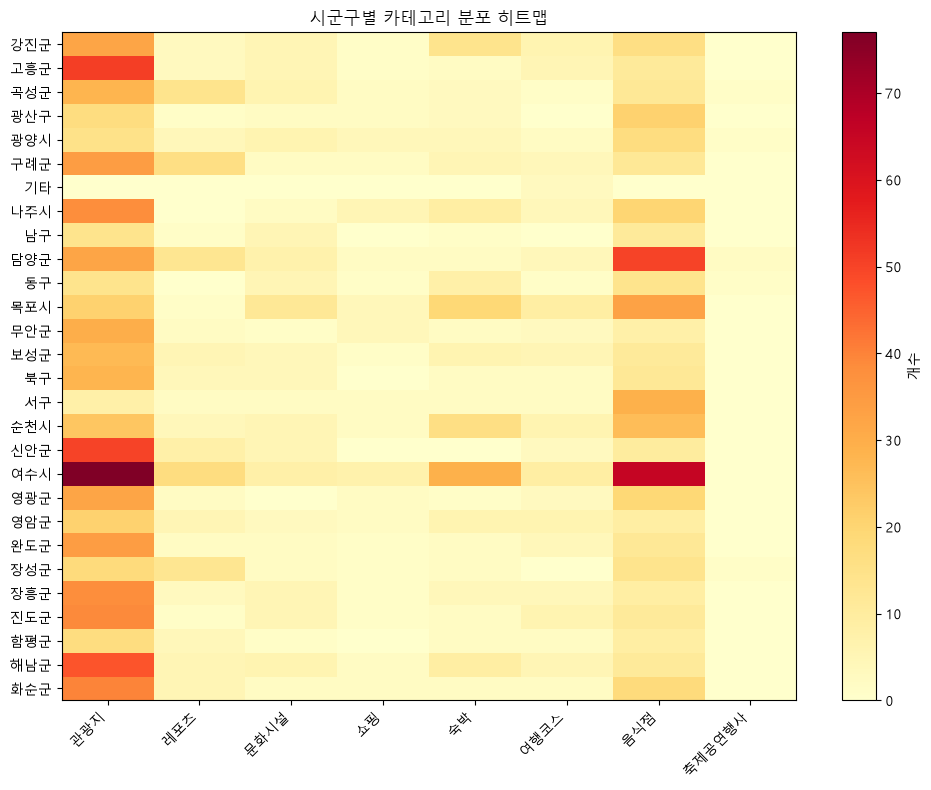

In [103]:
import numpy as np

cross = pd.crosstab(df["sigungu_name"], df["category"])

plt.figure(figsize=(10, 8))
plt.imshow(cross, cmap="YlOrRd", aspect="auto")
plt.colorbar(label="개수")
plt.xticks(range(len(cross.columns)), cross.columns, rotation=45, ha="right")
plt.yticks(range(len(cross.index)), cross.index)
plt.title("시군구별 카테고리 분포 히트맵")
plt.tight_layout()
plt.show()

## 편의시설 보유 비율

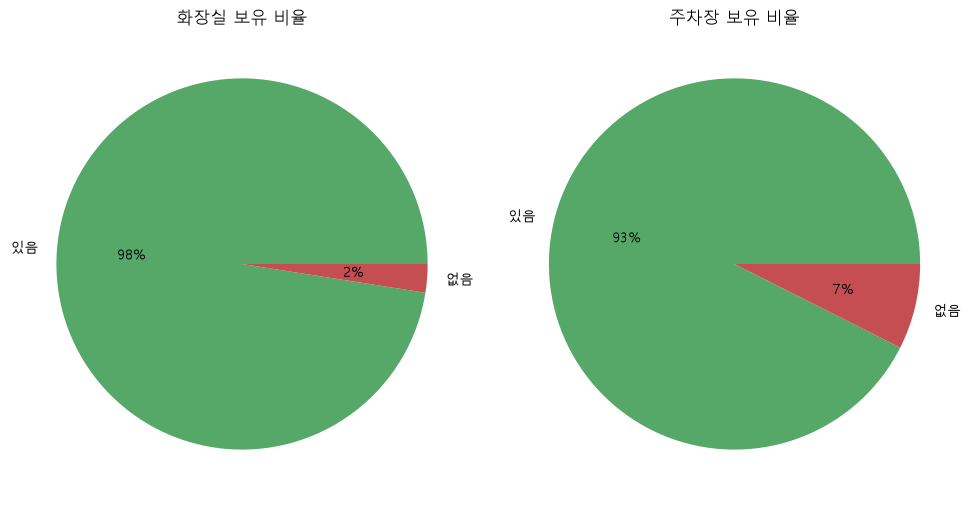

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

restroom_counts = df_market_gj["has_restroom"].value_counts()
axes[0].pie(restroom_counts, labels=["있음", "없음"], autopct="%1.0f%%", colors=["#55A868", "#C44E52"])
axes[0].set_title("화장실 보유 비율")

parking_counts = df_market_gj["has_parking"].value_counts()
axes[1].pie(parking_counts, labels=["있음", "없음"], autopct="%1.0f%%", colors=["#55A868", "#C44E52"])
axes[1].set_title("주차장 보유 비율")

plt.tight_layout()
plt.show()

## 어떤 품목이 가장 흔한가

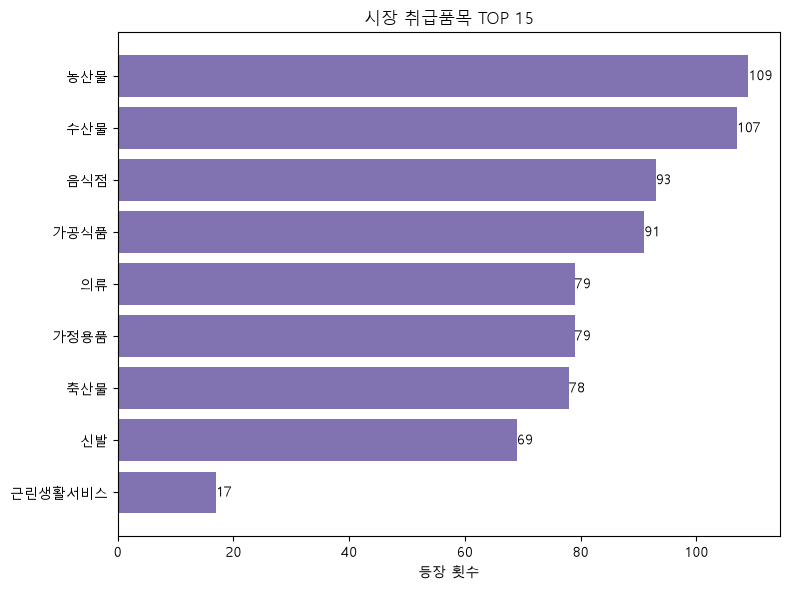

In [132]:
from collections import Counter

all_items = []
for items_list in df_market_gj["items"]:
    all_items.extend(items_list)

item_counts = Counter(all_items).most_common(15)
labels, counts = zip(*item_counts)

plt.figure(figsize=(8, 6))
bars = plt.barh(labels, counts, color="#8172B2")
for bar in bars:
    w = bar.get_width()
    plt.text(w, bar.get_y()+bar.get_height()/2, int(w), ha="left", va="center")
plt.title("시장 취급품목 TOP 15")
plt.xlabel("등장 횟수")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 관광지 전처리 함수 수정

한국 좌표 범위(위도 33~39, 경도 124~132)를 벗어나면 애초에 None으로 처리하거나 제외하는 로직

In [139]:
def is_valid_korea_coord(lat, lng):
    """한국 영토 범위 안의 좌표인지 확인"""
    if lat is None or lng is None:
        return False
    return 33 <= lat <= 39 and 124 <= lng <= 132

In [134]:
def preprocess_attraction(item):
    area_code = item.get("areacode")
    sigungu_code = item.get("sigungucode")
    sigungu_key = f"{area_code}_{sigungu_code}"

    lat = float(item["mapy"]) if item.get("mapy") else None
    lng = float(item["mapx"]) if item.get("mapx") else None

    # [전처리 종류: 이상치 검증] 한국 범위 밖이면 좌표 자체를 무효 처리
    if not is_valid_korea_coord(lat, lng):
        lat, lng = None, None

    return {
        "content_id": item.get("contentid"),
        "name": item.get("title"),
        "address": combine_address(item),
        "image": item.get("firstimage") or None,
        "category": CONTENT_TYPE_NAMES.get(item.get("contenttypeid"), "기타"),
        "lcls1_name": lcls_full_map.get(item.get("lclsSystm1"), "미분류"),
        "lcls2_name": lcls_full_map.get(item.get("lclsSystm2"), "미분류"),
        "lcls3_name": lcls_full_map.get(item.get("lclsSystm3"), "미분류"),
        "area_code": area_code,
        "sigungu_name": sigungu_full_map.get(sigungu_key, "기타"),
        "lat": lat,
        "lng": lng,
        "tel": item.get("tel") or None,
        "region": item.get("_region"),
    }

In [135]:
df = pd.DataFrame([preprocess_attraction(i) for i in raw_items])
df = df.drop_duplicates(subset="content_id")
df = df.dropna(subset=["name", "lat", "lng"])  # lat/lng가 None이면 여기서 걸러짐

print("전처리 후 관광지 데이터 크기:", df.shape)

전처리 후 관광지 데이터 크기: (1874, 14)


## 시장 전처리 수정

In [136]:
def preprocess_market(row):
    lat = float(row["위도"]) if pd.notna(row.get("위도")) else None
    lng = float(row["경도"]) if pd.notna(row.get("경도")) else None

    # [전처리 종류: 이상치 검증]
    if not is_valid_korea_coord(lat, lng):
        lat, lng = None, None

    return {
        "name": row.get("시장명"),
        "market_type": row.get("시장유형"),
        "address": combine_market_address(row),
        "open_cycle": row.get("시장개설주기"),
        "lat": lat,
        "lng": lng,
        "items": str(row["취급품목"]).split("+") if pd.notna(row.get("취급품목")) else [],
        "has_restroom": row.get("공중화장실보유여부") == "Y",
        "has_parking": row.get("주차장보유여부") == "Y",
        "store_count": pd.to_numeric(row.get("점포수"), errors="coerce"),
    }

In [137]:
df_market = pd.DataFrame([preprocess_market(row) for _, row in df_market_raw.iterrows()])
df_market = df_market.dropna(subset=["name", "lat", "lng"])  # 여기서 이상 좌표 제외됨
df_market = df_market.drop_duplicates(subset=["name", "address"])

df_market_gj = df_market[df_market["address"].str.contains("광주광역시|전라남도", na=False)]

print(f"광주/전남 전통시장: {len(df_market_gj)}개")

광주/전남 전통시장: 121개
